## Домашнее задание 2. Tiny ImageNet Challenge (20 баллов + 6 баллов + бонус)

В этом задании Вам предстоит обучить свёрточную нейросеть для решения задачи мультиклассовой классификации на датасете [Tiny ImageNet](https://www.kaggle.com/c/tiny-imagenet) (200 классов, по 500 изображений на класс в трейне и по 50 в валидации и тесте).

## Критерии оценки

* 3 балла за отчет. Без отчёта с графиками лосса и метрики (``accuracy@1``) на обучении работа **не принимается!**
* 3 балла за использование **интерактивного** (не изобретайте велосипед с помощью `plt.plot`) инструмента для просмотра прогресса, например, TensorBoard или Wandb.    
    *В Wandb также можно писать отчёты по вашим данным, попробуйте, это очень экономит время.*
* `[7;14]+bonus(accuracy@1_test)` баллов за точность на **тестовом** наборе: 7 за достижение нижнего порога, далее линейно до верхнего (14). Bonus описан ниже в графике.
* Bonus за первые три места (5/3/1)


## Объяснение оценок

* *Тест*: это часть набора данных, идентичная валидации, но лейблы известны только нам (не пытайтесь копаться в ImageNet-1K).
* *Как отправить*:
   * Не меняйте этот ноутбук, ваш код должен отработать в нём для корректной проверки инференса. Обучать можно как угодно, например, в нём же с флагом `DO_TRAIN=True`, в своём ноутбуке или из консоли.
   * После того, как вы обучили свою сеть, [сохраните веса](https://pytorch.org/tutorials/recipes/recipes/saving_and_loading_a_general_checkpoint.html) в «*checkpoint.pth*» с помощью `model.state_dict()` и ` torch.save()`.
   * Установите `DO_TRAIN = False`, нажмите «Перезапустить и запустить все ячейки» и убедитесь, что точность проверки на валидации рассчитана правильно.
   * Вычислите контрольную сумму MD5 для «*checkpoint.pth*» (например, запустите `!md5sum checkpoint.pth`) и вставьте ее в ваш «*solution.py*» (`get_checkpoint_metadata()`). Вы будете оштрафованы, если эта контрольная сумма не будет соответствовать отправленному вами файлу.
   * Загрузите «*checkpoint.pth*» на Google Диск, скопируйте на него ссылку, доступную только для просмотра, и вставьте ее также в «*solution.py*».

* *Отчет*: PDF, свободная форма (можно написать в Markdown или .ipynb, главное сконвертировать в PDF в конце; отчёт в Wandb просто присылайте ссылкой), следует упомянуть:
   * Ваша история настроек и улучшений. Как вы начинали, что искали. (*Я проанализировал те и эти документы/источники/репорты/статьи. Я попробовал то и это, чтобы адаптировать их к моей задаче. ...*)
   * Какие архитектуры вы пробовали? Какие из них не сработали и почему, по Вашему мнению? Какую выбрали на финальный сабмит и почему?
   * То же самое касается метода обучения (batch size, алгоритм оптимизации, количество итераций...): что и почему?
   * То же самое касается методов предотвращения переобучения (регуляризации). Какие из них вы пробовали? Каковы были их последствия и можете ли вы объяснить, почему?
   * **Самое главное**: вы получили глубокие знания. Можете ли вы отрефлексировать и привести несколько примеров того, как опыт этого упражнения повлияет на ваше обучение будущих нейронных сетей? (хитрости, эвристики, выводы, наблюдения)
   * **Перечислите и сошлитесь на все внешние источники кода, если вы их использовали**.
* *Инструмент логгирования*: дополните отчет скриншотами графиков точности и лосса (на трейне и на валидации) с течением времени.

## Ограничения

* Никаких претрейнов.
* Не увеличивайте изображения (например, не изменяйте их размер до $224 \times 224$ или $256 \times 256$).

## Советы

* **Одно изменение за раз**: не тестируйте несколько новых вещей одновременно (если вы не очень уверены, что они будут работать). Обучите модель, внесите одно изменение, обучите снова.
* Много гуглите: постарайтесь изобрести как можно меньше велосипедов. Черпайте вдохновение из туториалов PyTorch, GitHub, блогов...
* Используйте графический процессор.
* Регуляризация очень важна: L2, batch norm, early stopping, аугментации, семплирование...
* Уделяйте большое внимание графикам точности и потерь (например, в TensorBoard). Отслеживайте неудачи как можно раньше, прекращайте неудачные эксперименты как можно раньше.
* 2-3 часов обучения (в Colab) должно быть достаточно для большинства моделей, возможно, 4-6 часов, если вы экспериментируете.
* Время от времени сохраняйте чекпоинты вместе со стейтом оптимизатора на случай, если что-то пойдет не так (оптимизация расходится, Colab отключается...).
* Не используйте слишком большие батчи, они могут работать медленно и требовать много памяти. Это справедливо и для инференса.
* Также не забудьте использовать `torch.no_grad()` и `.eval()` во время инференса.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

def score_hw2(score, low=25, up=50, min_points=7, max_points=14):
    coef_ = (min_points * up - max_points * low) / (up - low)
    return  (score >= low) * ((min_points - coef_) / low * score + coef_)

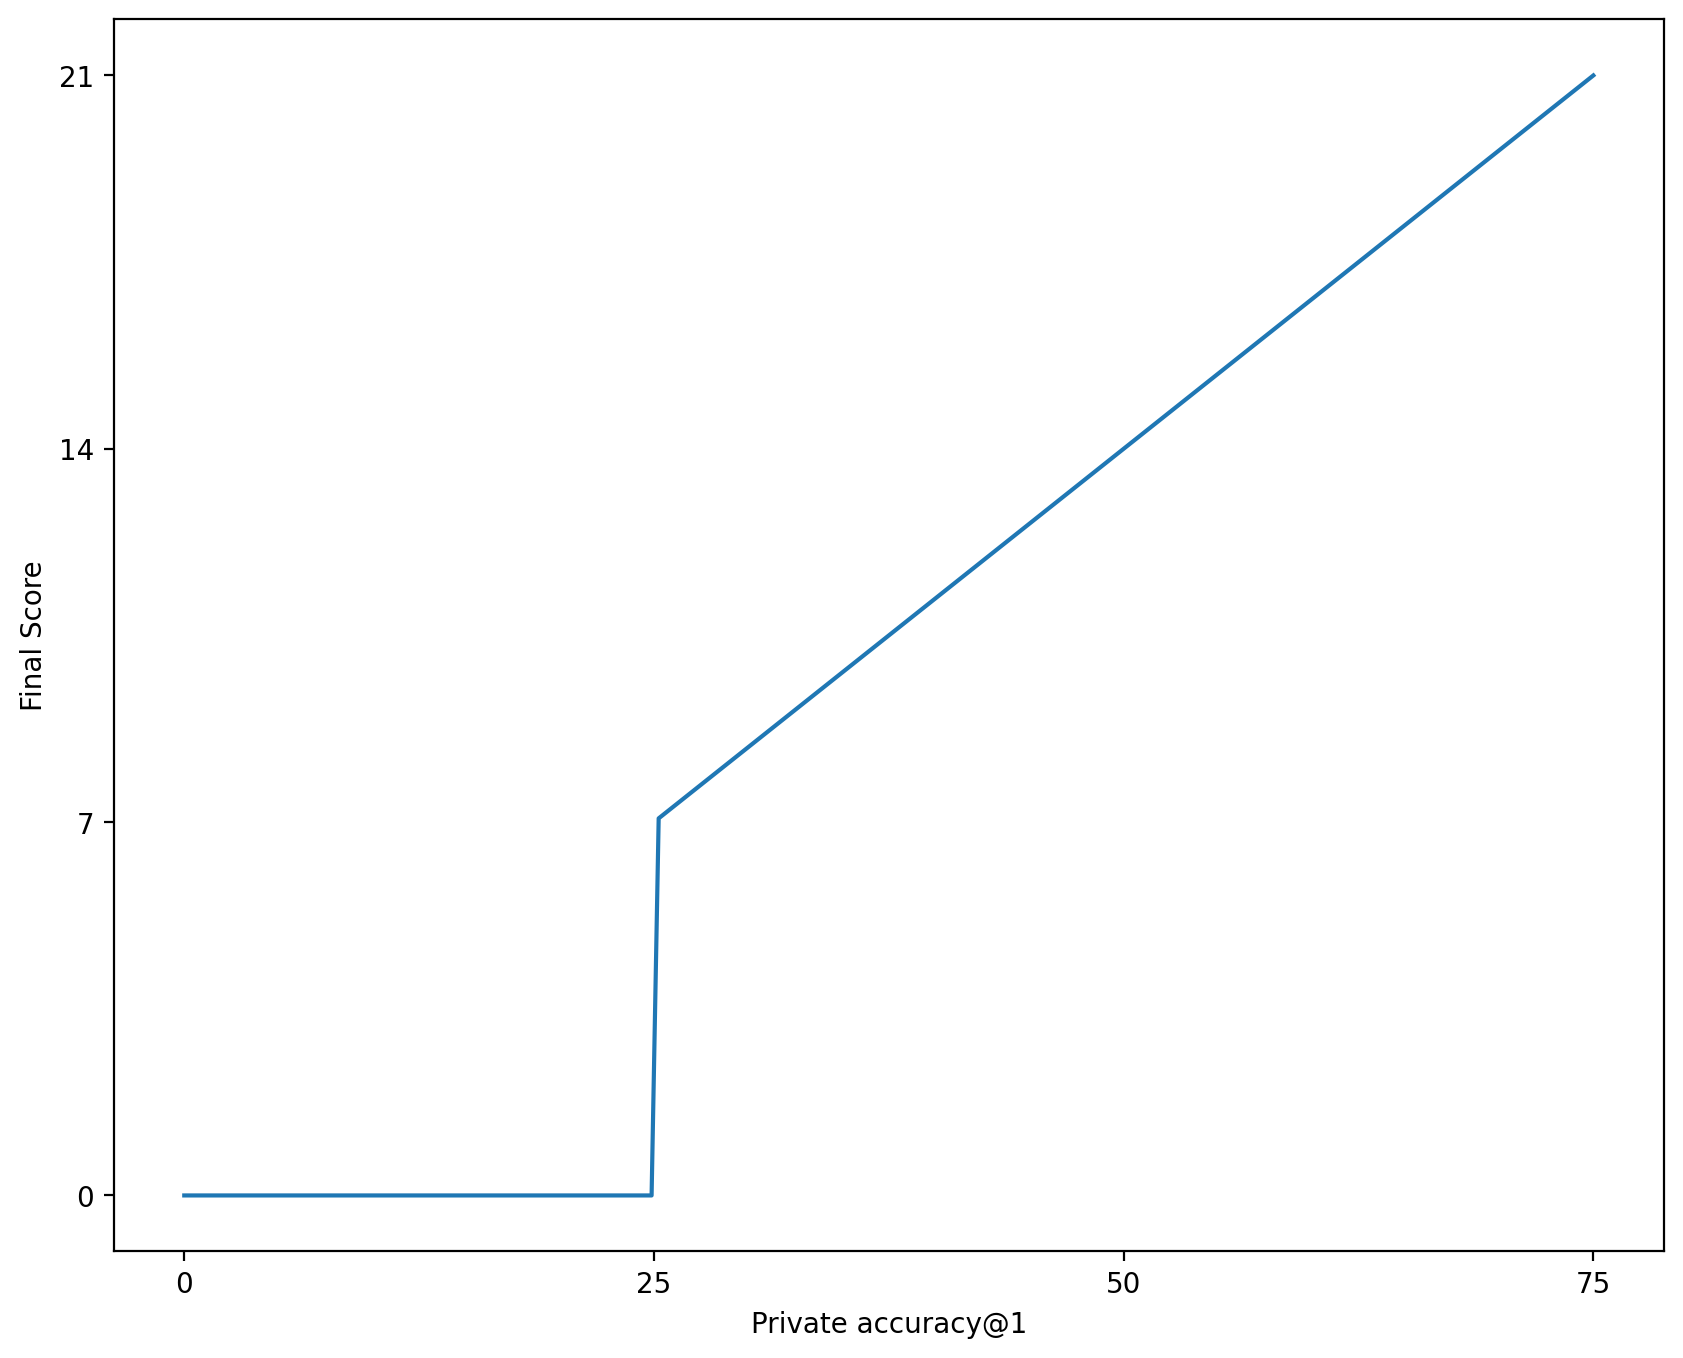

In [2]:
score = np.linspace(0, 75, 200)

plt.figure(figsize=(10, 8))
plt.xlabel("Private accuracy@1")
plt.ylabel("Final Score")
plt.plot(score, score_hw2(score))
plt.yticks(score_hw2(np.array([0, 25, 50, 75])))
plt.xticks([0, 25, 50, 75])
plt.show()

--------

In [3]:
# Determine the locations of auxiliary libraries and datasets.
# `AUX_DATA_ROOT` is where 'tiny-imagenet.zip' is.

# Detect if we are in Google Colaboratory
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

from pathlib import Path
if IN_COLAB:
    google.colab.drive.mount("/content/drive")

    # Change this if you created the shortcut in a different location
    AUX_DATA_ROOT = Path("/content/drive/My Drive/ML3_2024/HW2")

    assert AUX_DATA_ROOT.is_dir(), "Have you forgot to 'Add a shortcut to Drive'?"

    import sys
    sys.path.append(str(AUX_DATA_ROOT))
else:
    # Change this if you created the shortcut in a different location
    AUX_DATA_ROOT = Path(".")

In [4]:
import os
from urllib.request import urlretrieve

def download_dataset(path, url='http://cs231n.stanford.edu/tiny-imagenet-200.zip'):
    dataset_name = 'tiny-imagenet-200'

    if os.path.exists(os.path.join(path, dataset_name, "val", "n01443537")):
        print("%s already exists, skipping download" % os.path.join(path, dataset_name))
        return
    elif not os.path.exists(os.path.join(path, 'tiny-imagenet-200' + ".zip")):
        print("Dataset doesn't exist or is broken, downloading it")
        urlretrieve(url, os.path.join(path, dataset_name + ".zip"))

    import zipfile
    with zipfile.ZipFile(os.path.join(path, 'tiny-imagenet-200' + ".zip"), 'r') as archive:
        archive.extractall()

    # move validation images to subfolders by class
    val_root = os.path.join(".", dataset_name, "val")
    with open(os.path.join(val_root, "val_annotations.txt"), 'r') as f:
        for image_filename, class_name, _, _, _, _ in map(str.split, f):
            class_path = os.path.join(val_root, class_name)
            os.makedirs(class_path, exist_ok=True)
            os.rename(
                os.path.join(val_root, "images", image_filename),
                os.path.join(class_path, image_filename))

    os.rmdir(os.path.join(val_root, "images"))
    os.remove(os.path.join(val_root, "val_annotations.txt"))


In [5]:
# Your solution should be in the same directory and named solution.py
%load_ext autoreload
%autoreload 1

%aimport solution

In [6]:
# If `True`, will train the model from scratch and validate it.
# If `False`, instead of training will load weights from './checkpoint.pth'.
# When grading, we will test both cases.
DO_TRAIN = False

In [7]:
# Put training and validation images in `./tiny-imagenet-200/train` and `./tiny-imagenet-200/val`:
download_dataset(AUX_DATA_ROOT)

./tiny-imagenet-200 already exists, skipping download


In [8]:
root_datasets = "./"

In [9]:
# Initialize dataloaders
train_dataloader = solution.get_dataloader(f"{root_datasets}/tiny-imagenet-200/", 'train')
val_dataloader   = solution.get_dataloader(f"{root_datasets}/tiny-imagenet-200/", 'val')
test_dataloader = solution.get_dataloader(f"{root_datasets}/tiny-imagenet-200/", 'test')
# Initialize the raw model
model = solution.get_model()

In [10]:
if DO_TRAIN:
    # Train from scratch
    optimizer = solution.get_optimizer(model)
    solution.train_on_tinyimagenet(train_dataloader, val_dataloader, model, optimizer)
else:
    # Download the checkpoint and initialize model weights from it
    import urllib
    import subprocess

    penalize = False

    # Get your link and checksum
    claimed_md5_checksum, google_drive_link = solution.get_checkpoint_metadata()

    # Use your link to download "checkpoint.pth"
    !pip install -U gdown
    !gdown --id {urllib.parse.urlparse(google_drive_link).path.split('/')[-2]} -O checkpoint.pth

    try:
        # Compute the actual checksum
        real_md5_checksum = subprocess.check_output(
            ["md5sum", "checkpoint.pth"]).decode().split()[0]
    except subprocess.CalledProcessError as err:
        # Couldn't download or the filename isn't "checkpoint.pth"
        print(f"Wrong link or filename: {err}")
        penalize = True
    else:
        # The trained checkpoint is different from the one submitted
        if real_md5_checksum != claimed_md5_checksum:
            print("Checksums differ! Late submission?")
            penalize = True

    if penalize:
        print("🔫 Prepare the penalizer! 🔫")

    # Finally load weights
    solution.load_weights(model, "./checkpoint.pth")

  Using cached gdown-5.2.0-py3-none-any.whl.metadata (5.8 kB)
Using cached gdown-5.2.0-py3-none-any.whl (18 kB)
  Attempting uninstall: gdown
    Found existing installation: gdown 4.4.0
    Uninstalling gdown-4.4.0:
      Successfully uninstalled gdown-4.4.0
/Users/n-zagainov/.local/share/mamba/envs/aim/lib/python3.12/site-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1HI44ZrLwB_oVY7da_foM6ujCqsjoTRl3
From (redirected): https://drive.google.com/uc?id=1HI44ZrLwB_oVY7da_foM6ujCqsjoTRl3&confirm=t&uuid=0bcde018-b229-469e-8c96-49db96616eff
To: /Users/n-zagainov/aim/ai-masters/ml_3_2025/hw2/checkpoint.pth
100%|██████████████████████████████████████| 45.2M/45.2M [00:03<00:00, 11.8MB/s]


In [11]:
example_batch, example_batch_labels = next(iter(train_dataloader))

In [12]:
# Classify some validation samples
import torch

example_batch, example_batch_labels = next(iter(val_dataloader))
model.eval()
with torch.no_grad():
    _, example_predicted_labels = solution.predict(model, example_batch).max(1)

print("Predicted class / Ground truth class")
for predicted, gt in list(zip(example_predicted_labels, example_batch_labels))[:15]:
    print("{:03d} / {:03d}".format(predicted, gt))

Predicted class / Ground truth class
067 / 067
067 / 067
067 / 067
067 / 067
067 / 067
048 / 067
080 / 067
065 / 067
193 / 067
067 / 067
153 / 067
135 / 067
067 / 067
172 / 067
067 / 067


In [13]:
# Print validation accuracy
val_accuracy, _ = solution.validate(val_dataloader, model)
val_accuracy *= 100
assert 1.5 <= val_accuracy <= 100.0
print("Validation accuracy: %.2f%%" % val_accuracy)

Validation accuracy: 51.32%


In [ ]:
import pandas as pd

In [27]:
all_preds = []
with torch.no_grad():
    for img_paths, imgs in test_dataloader:
        imgs = imgs.to(next(model.parameters()).device)
        logits = model(imgs).cpu()
        preds = torch.argmax(logits, dim=-1).tolist()
        all_preds.extend([(Path(path).name, train_dataloader.dataset.idx_to_class[pred]) for path, pred in zip(img_paths, preds)])


In [29]:
submission_df = pd.DataFrame(all_preds, columns=["id", "pred"])
submission_df.sort_values(by="id", inplace=True)
submission_df.to_csv("submission.csv", index=False)